最终策略：
P(Retrieve | signal=0) = 0.3912
P(Retrieve | signal=1) = 0.9760
最近 50 个 episode 的平均 Reward = 0.6059
最近 50 个 episode 的经验 P(s_t = s_(t-1)) = 0.9003


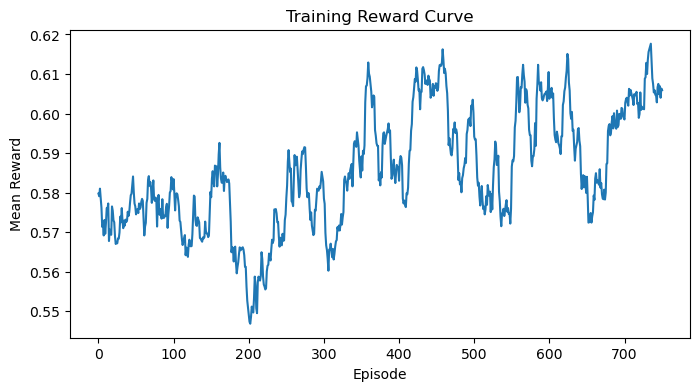

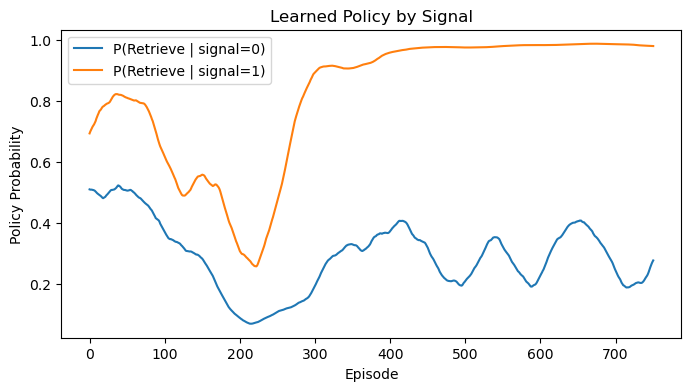

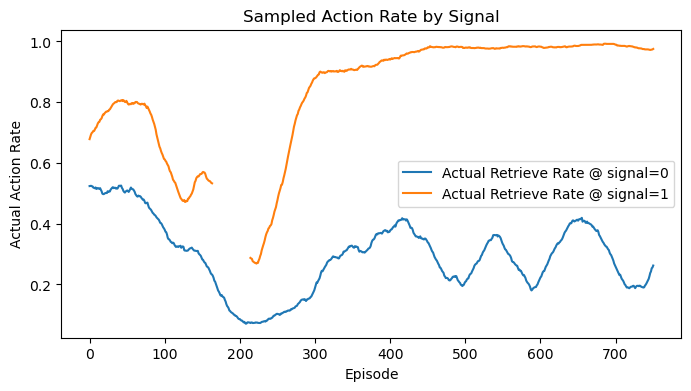

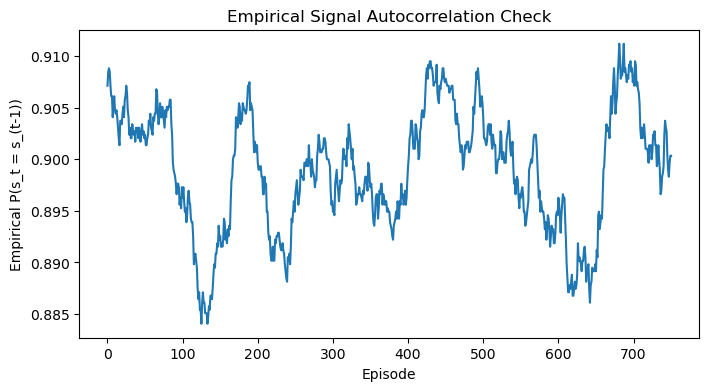


A. 基础统计
总 step 数 = 48000
signal=0 的 step 数 = 23481
signal=1 的 step 数 = 24519
signal=0 & ENCODE 数 = 16319
signal=0 & RETRIEVE 数 = 7162
signal=1 & ENCODE 数 = 4572
signal=1 & RETRIEVE 数 = 19947

B. signal=0 下：即时 reward 对比（最重要）
signal=0 & ENCODE   的平均即时 reward = 0.5217
signal=0 & RETRIEVE 的平均即时 reward = 0.5157
如果这两者非常接近，说明 signal=0 时 Encode 的优势不是即时兑现，而主要是未来兑现。

C. signal=0 下：return 对比（看延迟收益）
signal=0 & ENCODE   的平均 return = 12.4268
signal=0 & RETRIEVE 的平均 return = 12.2273
如果 return 上 ENCODE 更高，但即时 reward 没明显更高，就说明你的问题确实是 delayed credit。

D. signal=0 且接近 0->1 转换时：return 对比
接近转换: signal=0 & ENCODE   平均 return = 13.3176
接近转换: signal=0 & RETRIEVE 平均 return = 12.7967
远离转换: signal=0 & ENCODE   平均 return = 12.2153
远离转换: signal=0 & RETRIEVE 平均 return = 12.0955
如果“接近转换时 Encode 的 return 更高”，而“远离转换时优势变弱”，
就说明 signal=0 下的 Encode 价值是稀疏的、只在部分时刻兑现。

E. signal=0 下 recent coverage 与动作
signal=0 & ENCODE   时 recent_cov_before 平均 = 0.7317
signal=0 & RETRIEVE 时 recent_cov_before 平均 = 0.6443

F. 简要解释模板
你可以按下面逻

In [2]:
# =========================
# 0. 导入基础库
# =========================

import numpy as np
import matplotlib.pyplot as plt


# =========================
# 1. 定义玩具环境
# =========================

class ToyMemoryEnv:
    """
    极简环境：
    1) 一批固定物品，每个物品有固定隐藏价值
    2) 每轮先生成一个二元 signal:
       - 0 = novel
       - 1 = familiar
    3) signal 由二状态马尔可夫链生成
    4) 每轮展示两个物品
    """

    def __init__(
        self,
        n_items=200,
        value_levels=None,
        stay_prob=0.90,
        recent_buffer_size=4,
        seed=42
    ):
        self.rng = np.random.default_rng(seed)

        self.n_items = n_items
        self.stay_prob = stay_prob
        self.recent_buffer_size = recent_buffer_size

        if value_levels is None:
            value_levels = [0.0, 0.25, 0.5, 0.75, 1.0]

        self.value_levels = np.array(value_levels, dtype=float)
        self.prior_mean = float(np.mean(self.value_levels))

        # 固定每个 item 的真实价值
        self.item_values = self.rng.choice(self.value_levels, size=self.n_items, replace=True)

        self.reset()

    def reset(self):
        self.seen_items = set()
        self.unseen_items = set(range(self.n_items))
        self.recent_items = []
        self.prev_signal = int(self.rng.integers(0, 2))

    def sample_signal(self):
        if self.rng.random() < self.stay_prob:
            signal = self.prev_signal
        else:
            signal = 1 - self.prev_signal

        self.prev_signal = signal
        return int(signal)

    def _sample_two_from_recent(self):
        item_a = int(self.rng.choice(self.recent_items))
        item_b = int(self.rng.choice(self.recent_items))

        while item_b == item_a:
            item_b = int(self.rng.choice(self.recent_items))

        return item_a, item_b

    def sample_items(self, signal):
        # familiar: 优先 recent / seen
        if signal == 1:
            if len(set(self.recent_items)) >= 2:
                return self._sample_two_from_recent()
            elif len(self.seen_items) >= 2:
                pool = np.array(list(self.seen_items), dtype=int)
                item_a, item_b = self.rng.choice(pool, size=2, replace=False)
                return int(item_a), int(item_b)
            else:
                item_a, item_b = self.rng.choice(self.n_items, size=2, replace=False)
                return int(item_a), int(item_b)

        # novel: 优先 unseen
        else:
            if len(self.unseen_items) >= 2:
                pool = np.array(list(self.unseen_items), dtype=int)
                item_a, item_b = self.rng.choice(pool, size=2, replace=False)
                return int(item_a), int(item_b)
            else:
                item_a, item_b = self.rng.choice(self.n_items, size=2, replace=False)
                return int(item_a), int(item_b)

    def reveal(self, item_a, item_b):
        value_a = float(self.item_values[item_a])
        value_b = float(self.item_values[item_b])

        self.seen_items.add(item_a)
        self.seen_items.add(item_b)

        self.unseen_items.discard(item_a)
        self.unseen_items.discard(item_b)

        self.recent_items.extend([item_a, item_b])
        self.recent_items = self.recent_items[-self.recent_buffer_size:]

        return value_a, value_b


# =========================
# 2. 定义智能体
# =========================

class SimplePolicyAgent:
    """
    动作:
    - ENCODE   = 0
    - RETRIEVE = 1

    策略仅依赖 signal:
    P(Retrieve | signal=s) = sigmoid(theta[s])
    """

    ENCODE = 0
    RETRIEVE = 1

    def __init__(self, prior_mean=0.5, alpha=0.01, beta=0.05, seed=123):
        self.rng = np.random.default_rng(seed)

        self.prior_mean = prior_mean
        self.alpha = alpha
        self.beta = beta

        self.theta = np.zeros(2, dtype=float)
        self.baseline = np.zeros(2, dtype=float)

        self.memory = {}

    def reset_memory(self):
        self.memory = {}

    def retrieve_prob(self, signal):
        clipped_theta = np.clip(self.theta[signal], -20.0, 20.0)
        p = 1.0 / (1.0 + np.exp(-clipped_theta))
        return float(p)

    def sample_action(self, signal):
        p = self.retrieve_prob(signal)
        if self.rng.random() < p:
            action = self.RETRIEVE
        else:
            action = self.ENCODE
        return int(action), p

    def choose_by_retrieval(self, item_a, item_b):
        est_a = self.memory.get(item_a, self.prior_mean)
        est_b = self.memory.get(item_b, self.prior_mean)

        if est_a > est_b:
            return item_a
        elif est_b > est_a:
            return item_b
        else:
            if self.rng.random() < 0.5:
                return item_a
            else:
                return item_b

    def encode_pair(self, item_a, value_a, item_b, value_b):
        self.memory[item_a] = value_a
        self.memory[item_b] = value_b

    def update_policy(self, signals, actions, probs, returns):
        for signal, action, p, G in zip(signals, actions, probs, returns):
            advantage = G - self.baseline[signal]

            if action == self.RETRIEVE:
                grad_log_pi = 1.0 - p
            else:
                grad_log_pi = -p

            self.theta[signal] += self.alpha * advantage * grad_log_pi
            self.theta[signal] = np.clip(self.theta[signal], -8.0, 8.0)

            self.baseline[signal] += self.beta * advantage


# =========================
# 3. 辅助函数
# =========================

def discounted_returns(rewards, gamma=0.98):
    returns = np.zeros(len(rewards), dtype=float)
    running = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        running = rewards[t] + gamma * running
        returns[t] = running
    return returns


def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(x, kernel, mode="valid")


def compute_transition_proximity(signals, horizon=2):
    """
    对每个时间步 t：
    如果 signals[t] == 0，检查未来 horizon 步内是否发生 0 -> 1 转换。
    如果发生，则 near_transition[t] = True
    """
    signals = np.asarray(signals, dtype=int)
    T = len(signals)
    near = np.zeros(T, dtype=bool)

    for t in range(T):
        if signals[t] != 0:
            continue

        for k in range(1, horizon + 1):
            if t + k < T:
                # 检查在 [t+1, t+horizon] 内是否有 0->1
                if signals[t + k - 1] == 0 and signals[t + k] == 1:
                    near[t] = True
                    break

    return near


def recent_coverage(memory, recent_items):
    """
    recent buffer 里已有多少比例在 memory 中
    """
    if len(recent_items) == 0:
        return np.nan

    uniq = list(set(recent_items))
    hits = sum(1 for item in uniq if item in memory)
    return hits / len(uniq)


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    return float(np.mean(x))


def print_block(title):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)


# =========================
# 4. 训练主循环（含完整诊断日志）
# =========================

def train_mvp_with_diagnostics(
    n_episodes=800,
    steps_per_episode=60,
    n_items=200,
    stay_prob=0.90,
    recent_buffer_size=4,
    gamma=0.98,
    alpha=0.01,
    beta=0.05,
    seed=7
):
    env = ToyMemoryEnv(
        n_items=n_items,
        stay_prob=stay_prob,
        recent_buffer_size=recent_buffer_size,
        seed=seed
    )

    agent = SimplePolicyAgent(
        prior_mean=env.prior_mean,
        alpha=alpha,
        beta=beta,
        seed=seed + 1
    )

    episode_reward_history = []
    retrieve_prob_signal0_history = []
    retrieve_prob_signal1_history = []
    actual_retrieve_rate_signal0_history = []
    actual_retrieve_rate_signal1_history = []
    stay_rate_history = []

    # 这是完整 step-level 日志
    step_log = []

    for episode in range(n_episodes):
        env.reset()
        agent.reset_memory()

        signals = []
        actions = []
        probs = []
        rewards = []

        # 本 episode 的逐步日志
        episode_step_log = []

        for step in range(steps_per_episode):
            signal = env.sample_signal()
            item_a, item_b = env.sample_items(signal)

            action, p_retrieve = agent.sample_action(signal)

            # 记录动作前的 memory / recent 状态，便于诊断
            memory_size_before = len(agent.memory)
            recent_items_before = list(env.recent_items)
            recent_cov_before = recent_coverage(agent.memory, env.recent_items)

            if action == agent.RETRIEVE:
                chosen_item = agent.choose_by_retrieval(item_a, item_b)
                choice_mode = "retrieve"
            else:
                if agent.rng.random() < 0.5:
                    chosen_item = item_a
                else:
                    chosen_item = item_b
                choice_mode = "random_guess_after_encode"

            reward = float(env.item_values[chosen_item])

            value_a, value_b = env.reveal(item_a, item_b)

            if action == agent.ENCODE:
                agent.encode_pair(item_a, value_a, item_b, value_b)

            # 先存本步核心日志
            episode_step_log.append({
                "episode": int(episode),
                "t": int(step),
                "signal": int(signal),
                "action": int(action),   # 0=ENCODE, 1=RETRIEVE
                "action_name": "ENCODE" if action == agent.ENCODE else "RETRIEVE",
                "p_retrieve": float(p_retrieve),

                "item_a": int(item_a),
                "item_b": int(item_b),
                "value_a": float(value_a),
                "value_b": float(value_b),
                "chosen_item": int(chosen_item),
                "reward": float(reward),

                "memory_size_before": int(memory_size_before),
                "recent_items_before": recent_items_before,
                "recent_cov_before": float(recent_cov_before) if not np.isnan(recent_cov_before) else np.nan,

                "choice_mode": choice_mode,
            })

            signals.append(signal)
            actions.append(action)
            probs.append(p_retrieve)
            rewards.append(reward)

        # episode 结束后计算 return
        returns = discounted_returns(rewards, gamma=gamma)

        # 判断每一步是否接近 0->1 转换
        horizon = max(1, recent_buffer_size // 2)
        near_transition = compute_transition_proximity(signals, horizon=horizon)

        # 把 return / near_transition 回填到日志里
        for t in range(len(episode_step_log)):
            episode_step_log[t]["return"] = float(returns[t])
            episode_step_log[t]["near_transition"] = bool(near_transition[t])

        # 合并到总日志
        step_log.extend(episode_step_log)

        # 再做策略更新
        agent.update_policy(signals, actions, probs, returns)

        signals_np = np.array(signals, dtype=int)
        actions_np = np.array(actions, dtype=int)
        rewards_np = np.array(rewards, dtype=float)

        episode_reward_history.append(float(np.mean(rewards_np)))
        retrieve_prob_signal0_history.append(agent.retrieve_prob(0))
        retrieve_prob_signal1_history.append(agent.retrieve_prob(1))

        if np.any(signals_np == 0):
            rate0 = float(np.mean(actions_np[signals_np == 0] == agent.RETRIEVE))
        else:
            rate0 = np.nan

        if np.any(signals_np == 1):
            rate1 = float(np.mean(actions_np[signals_np == 1] == agent.RETRIEVE))
        else:
            rate1 = np.nan

        actual_retrieve_rate_signal0_history.append(rate0)
        actual_retrieve_rate_signal1_history.append(rate1)

        if len(signals_np) >= 2:
            stay_rate = float(np.mean(signals_np[1:] == signals_np[:-1]))
        else:
            stay_rate = np.nan

        stay_rate_history.append(stay_rate)

    history = {
        "episode_reward": np.array(episode_reward_history, dtype=float),
        "retrieve_prob_signal0": np.array(retrieve_prob_signal0_history, dtype=float),
        "retrieve_prob_signal1": np.array(retrieve_prob_signal1_history, dtype=float),
        "actual_retrieve_rate_signal0": np.array(actual_retrieve_rate_signal0_history, dtype=float),
        "actual_retrieve_rate_signal1": np.array(actual_retrieve_rate_signal1_history, dtype=float),
        "signal_stay_rate": np.array(stay_rate_history, dtype=float),
        "step_log": step_log,
    }

    return agent, history


# =========================
# 5. 训练曲线
# =========================

def plot_training_curves(history, smooth_window=50):
    reward_curve = history["episode_reward"]
    p0_curve = history["retrieve_prob_signal0"]
    p1_curve = history["retrieve_prob_signal1"]
    a0_curve = history["actual_retrieve_rate_signal0"]
    a1_curve = history["actual_retrieve_rate_signal1"]
    stay_curve = history["signal_stay_rate"]

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(reward_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Mean Reward")
    plt.title("Training Reward Curve")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(p0_curve, smooth_window), label="P(Retrieve | signal=0)")
    plt.plot(moving_average(p1_curve, smooth_window), label="P(Retrieve | signal=1)")
    plt.xlabel("Episode")
    plt.ylabel("Policy Probability")
    plt.title("Learned Policy by Signal")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(a0_curve, smooth_window), label="Actual Retrieve Rate @ signal=0")
    plt.plot(moving_average(a1_curve, smooth_window), label="Actual Retrieve Rate @ signal=1")
    plt.xlabel("Episode")
    plt.ylabel("Actual Action Rate")
    plt.title("Sampled Action Rate by Signal")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(stay_curve, smooth_window))
    plt.xlabel("Episode")
    plt.ylabel("Empirical P(s_t = s_(t-1))")
    plt.title("Empirical Signal Autocorrelation Check")
    plt.show()


# =========================
# 6. 诊断输出函数
# =========================

def inspect_diagnostics(history):
    """
    直接打印你最关心的归因信息：
    1) signal=0 下，Encode / Retrieve 的即时 reward 对比
    2) signal=0 下，Encode / Retrieve 的 return 对比
    3) signal=0 且接近 0->1 转换时，两动作的 return 对比
    """
    log = history["step_log"]

    # 转成便于筛选的列表
    sig0 = [x for x in log if x["signal"] == 0]
    sig1 = [x for x in log if x["signal"] == 1]

    sig0_enc = [x for x in sig0 if x["action"] == 0]
    sig0_ret = [x for x in sig0 if x["action"] == 1]

    sig1_enc = [x for x in sig1 if x["action"] == 0]
    sig1_ret = [x for x in sig1 if x["action"] == 1]

    print_block("A. 基础统计")
    print(f"总 step 数 = {len(log)}")
    print(f"signal=0 的 step 数 = {len(sig0)}")
    print(f"signal=1 的 step 数 = {len(sig1)}")
    print(f"signal=0 & ENCODE 数 = {len(sig0_enc)}")
    print(f"signal=0 & RETRIEVE 数 = {len(sig0_ret)}")
    print(f"signal=1 & ENCODE 数 = {len(sig1_enc)}")
    print(f"signal=1 & RETRIEVE 数 = {len(sig1_ret)}")

    print_block("B. signal=0 下：即时 reward 对比（最重要）")
    sig0_enc_reward = [x["reward"] for x in sig0_enc]
    sig0_ret_reward = [x["reward"] for x in sig0_ret]
    print(f"signal=0 & ENCODE   的平均即时 reward = {safe_mean(sig0_enc_reward):.4f}")
    print(f"signal=0 & RETRIEVE 的平均即时 reward = {safe_mean(sig0_ret_reward):.4f}")
    print("如果这两者非常接近，说明 signal=0 时 Encode 的优势不是即时兑现，而主要是未来兑现。")

    print_block("C. signal=0 下：return 对比（看延迟收益）")
    sig0_enc_return = [x["return"] for x in sig0_enc]
    sig0_ret_return = [x["return"] for x in sig0_ret]
    print(f"signal=0 & ENCODE   的平均 return = {safe_mean(sig0_enc_return):.4f}")
    print(f"signal=0 & RETRIEVE 的平均 return = {safe_mean(sig0_ret_return):.4f}")
    print("如果 return 上 ENCODE 更高，但即时 reward 没明显更高，就说明你的问题确实是 delayed credit。")

    print_block("D. signal=0 且接近 0->1 转换时：return 对比")
    sig0_near = [x for x in sig0 if x["near_transition"]]
    sig0_far = [x for x in sig0 if not x["near_transition"]]

    sig0_near_enc = [x for x in sig0_near if x["action"] == 0]
    sig0_near_ret = [x for x in sig0_near if x["action"] == 1]

    sig0_far_enc = [x for x in sig0_far if x["action"] == 0]
    sig0_far_ret = [x for x in sig0_far if x["action"] == 1]

    print(f"接近转换: signal=0 & ENCODE   平均 return = {safe_mean([x['return'] for x in sig0_near_enc]):.4f}")
    print(f"接近转换: signal=0 & RETRIEVE 平均 return = {safe_mean([x['return'] for x in sig0_near_ret]):.4f}")
    print(f"远离转换: signal=0 & ENCODE   平均 return = {safe_mean([x['return'] for x in sig0_far_enc]):.4f}")
    print(f"远离转换: signal=0 & RETRIEVE 平均 return = {safe_mean([x['return'] for x in sig0_far_ret]):.4f}")

    print("如果“接近转换时 Encode 的 return 更高”，而“远离转换时优势变弱”，")
    print("就说明 signal=0 下的 Encode 价值是稀疏的、只在部分时刻兑现。")

    print_block("E. signal=0 下 recent coverage 与动作")
    sig0_enc_cov = [x["recent_cov_before"] for x in sig0_enc if not np.isnan(x["recent_cov_before"])]
    sig0_ret_cov = [x["recent_cov_before"] for x in sig0_ret if not np.isnan(x["recent_cov_before"])]
    print(f"signal=0 & ENCODE   时 recent_cov_before 平均 = {safe_mean(sig0_enc_cov):.4f}")
    print(f"signal=0 & RETRIEVE 时 recent_cov_before 平均 = {safe_mean(sig0_ret_cov):.4f}")

    print_block("F. 简要解释模板")
    print("你可以按下面逻辑理解结果：")
    print("1) 先看 B：signal=0 下两动作的即时 reward 是否几乎一样")
    print("2) 再看 C：signal=0 下 Encode 的 return 是否更高")
    print("3) 再看 D：这种 return 优势是否主要集中在接近 0->1 转换的步")
    print("如果答案是“是”，那就证明：")
    print("signal=0 时 Retrieve 概率压不下去，主要原因不是 bug，而是 Encode 的优势是延迟且稀疏的。")


# =========================
# 7. 直接运行
# =========================

agent, history = train_mvp_with_diagnostics(
    n_episodes=800,
    steps_per_episode=60,
    n_items=200,
    stay_prob=0.90,
    recent_buffer_size=4,
    gamma=0.98,
    alpha=0.01,
    beta=0.05,
    seed=7
)

print("最终策略：")
print(f"P(Retrieve | signal=0) = {agent.retrieve_prob(0):.4f}")
print(f"P(Retrieve | signal=1) = {agent.retrieve_prob(1):.4f}")
print(f"最近 50 个 episode 的平均 Reward = {np.mean(history['episode_reward'][-50:]):.4f}")
print(f"最近 50 个 episode 的经验 P(s_t = s_(t-1)) = {np.mean(history['signal_stay_rate'][-50:]):.4f}")

plot_training_curves(history, smooth_window=50)
inspect_diagnostics(history)

# 你如果想直接看前几条日志，可以取消下面注释：
# print(history["step_log"][:5])